04/16/2026

In [1]:
import numpy as np
import matplotlib.pyplot as plt

<ipython-input-4-08e7173333de>:13: RuntimeWarning: overflow encountered in double_scalars
  return -1000*y + 3000 - 2000*np.exp(-t)
<ipython-input-4-08e7173333de>:7: RuntimeWarning: invalid value encountered in double_scalars
  y_values[i] = y_values[i-1] + h * f(t_values[i-1], y_values[i-1])


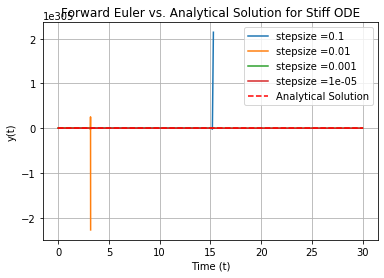

In [4]:
def forward_euler(f, y0, t0, tf, h):
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros_like(t_values)
    y_values[0] = y0
        
    for i in range(1, len(t_values)):
        y_values[i] = y_values[i-1] + h * f(t_values[i-1], y_values[i-1])
    
    return t_values, y_values

# Define the ODE
def f(t, y):
    return -1000*y + 3000 - 2000*np.exp(-t)

# Parameters
y0 = 0
t0 = 0
tf = 30
h = np.array([0.1, 0.01, 0.001, 0.00001])

# Solve using Forward Euler
for i in range(len(h)):
    t_values_fe, y_values_fe = forward_euler(f, y0, t0, tf, h[i])
    plt.plot(t_values_fe, y_values_fe, label=f"stepsize ={h[i]}")

t = np.arange(t0, tf + 0.1, 0.1)
y_exact = 3 - 0.998*np.exp(-1000*t) - 2.002*np.exp(-t)
plt.plot(t, y_exact, 'r--', label="Analytical Solution")
    
plt.xlabel('Time (t)')
plt.ylabel('y(t)')
plt.title('Forward Euler vs. Analytical Solution for Stiff ODE')
plt.legend()
plt.grid(True)
plt.show()

The given equation is a stiff ODE, so Euler's Forward Method is unstable for larger step sizes. However, as step size decreases, we sacrifice computional time for solution accuracy and risk having round-off errors.

Note: I tried running the code with h = 0.0000001 as given in the CH19 prompt, but my code does not run. I have only included stepsizes from 0.00001 to 0.1, and even then, h = 0.00001 takes a long time to compute.